## Active contour with shape constraint

We test **ITK** on a small synthetic page-like image.

### Goal
Try a shape-prior level-set method on a simple quadrilateral object.

### Energy idea
We are no longer using only image attraction.
We add a **shape term** to the evolution:

$$E_{total} = E_{image} + E_{propagation} + E_{curvature} + E_{advection} + \lambda_{shape} E_{shape}$$

Here:
- $E_{image}$ comes from the Sobel-based feature image
- $E_{curvature}$ keeps the contour regular
- $E_{advection}$ pulls the contour toward edges
- $E_{shape}$ encourages a page-like prior shape

So the new idea is simple: the contour should fit the image, but it should also stay close to a plausible page shape.

### Setup
- synthetic image
- mild noise and small clutter
- rectangle prior
- initial level set from the image extremities

The true object is a **slightly distorted quadrilateral**.
So this is a first test before trying real ECG pages.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
# noinspection PyPackageRequirements
import itk
from scipy import ndimage
from skimage import draw, filters, measure

RANDOM_SEED = 7
IMAGE_SHAPE = (180, 240)
FEATURE_SCALE = 25.0
FEATURE_BLACK_BORDER = 10
NOISE_STD = 0.01
BLUR_SIGMA = 1.0

PROPAGATION_SCALING = 1.0
CURVATURE_SCALING = 0.5
ADVECTION_SCALING = 1.0
SHAPE_PRIOR_SCALING = 0.3
REVERSE_EXPANSION = True
MAX_ITERATIONS = 102
MAX_RMS_ERROR = 0.005
NUM_LAYERS = 5

POLYGON_TOLERANCE = 6.0
INIT_TOP = 18
INIT_BOTTOM = 18
INIT_LEFT = 35
INIT_RIGHT = 18


In [10]:
def signed_distance(mask: np.ndarray) -> np.ndarray:
    """Return a signed distance map with negative values inside the mask."""
    outside = ndimage.distance_transform_edt(~mask)
    inside = ndimage.distance_transform_edt(mask)
    return (outside - inside).astype(np.float32)


def build_synthetic_quadrilateral_scene(shape: tuple[int, int], seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Create a simple quadrilateral object with mild clutter."""
    h, w = shape
    rng = np.random.default_rng(seed)

    image = np.full((h, w), 0.15, dtype=np.float32)
    true_mask = np.zeros((h, w), dtype=bool)

    ys = np.array([30, 24, 145, 150])
    xs = np.array([55, 185, 205, 40])
    rr, cc = draw.polygon(ys, xs, shape=image.shape)
    image[rr, cc] = 0.82
    true_mask[rr, cc] = True



    image = filters.gaussian(image, sigma=BLUR_SIGMA, preserve_range=True).astype(np.float32)
    image += NOISE_STD * rng.normal(size=image.shape).astype(np.float32)
    image = np.clip(image, 0.0, 1.0)
    return image, true_mask


def build_feature_image(gray: np.ndarray, feature_scale: float, black_border: int) -> np.ndarray:
    """Build an edge-based ITK feature image and suppress the outer frame."""
    grad = filters.sobel(gray).astype(np.float32)
    feature = (1.0 / (1.0 + feature_scale * grad)).astype(np.float32)
    if black_border > 0:
        feature[:black_border, :] = 0.0
        feature[-black_border:, :] = 0.0
        feature[:, :black_border] = 0.0
        feature[:, -black_border:] = 0.0
    return feature


def build_prior_and_initial_masks(shape: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    """Create a rectangle prior and an asymmetric border-based initial level set."""
    h, w = shape

    prior_mask = np.zeros((h, w), dtype=bool)
    prior_mask[35:145, 50:190] = True

    init_mask = np.zeros((h, w), dtype=bool)
    init_mask[INIT_TOP:h - INIT_BOTTOM, INIT_LEFT:w - INIT_RIGHT] = True
    return prior_mask, init_mask


def drop_duplicate_last_vertex(points: np.ndarray) -> np.ndarray:
    """Remove the closing vertex if it repeats the first one."""
    if len(points) > 1 and np.allclose(points[0], points[-1]):
        return points[:-1]
    return points


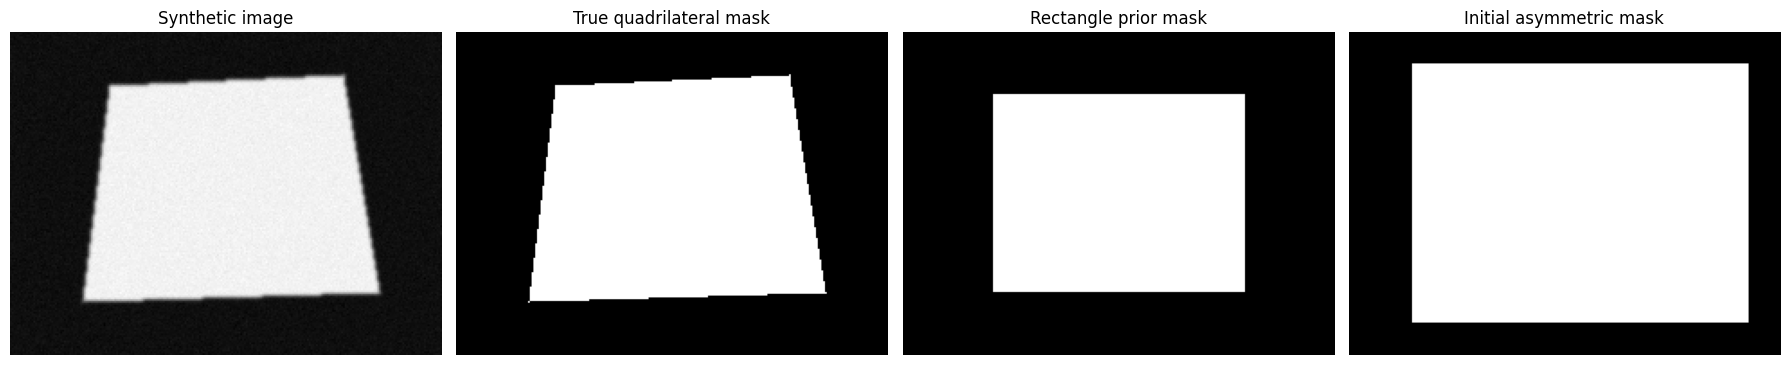

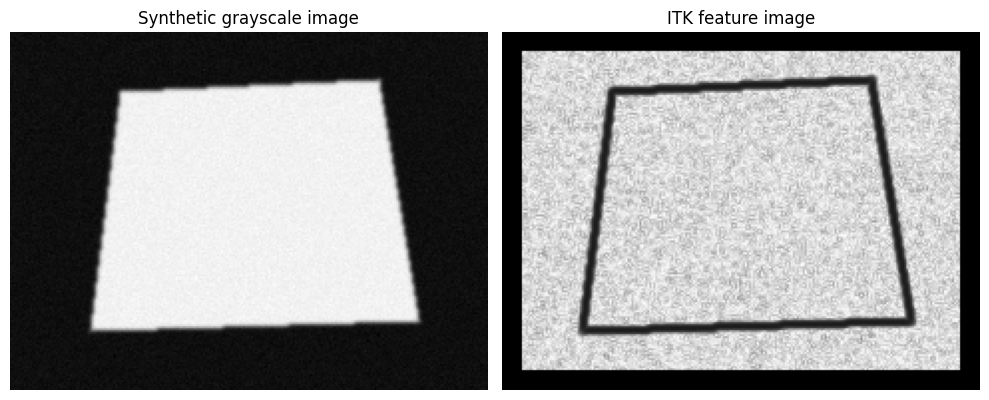

In [11]:
synthetic_img, true_mask = build_synthetic_quadrilateral_scene(IMAGE_SHAPE, RANDOM_SEED)
feature_img = build_feature_image(synthetic_img, FEATURE_SCALE, FEATURE_BLACK_BORDER)
prior_mask, init_mask = build_prior_and_initial_masks(IMAGE_SHAPE)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(synthetic_img, cmap='gray')
axes[0].set_title('Synthetic image')
axes[0].axis('off')
axes[1].imshow(true_mask, cmap='gray')
axes[1].set_title('True quadrilateral mask')
axes[1].axis('off')
axes[2].imshow(prior_mask, cmap='gray')
axes[2].set_title('Rectangle prior mask')
axes[2].axis('off')
axes[3].imshow(init_mask, cmap='gray')
axes[3].set_title('Initial asymmetric mask')
axes[3].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(synthetic_img, cmap='gray')
axes[0].set_title('Synthetic grayscale image')
axes[0].axis('off')
axes[1].imshow(feature_img, cmap='gray')
axes[1].set_title('ITK feature image')
axes[1].axis('off')
plt.tight_layout()
plt.show()


In [12]:
ImageType = itk.Image[itk.F, 2]

feature_itk = itk.image_from_array(feature_img.astype(np.float32))
init_levelset_itk = itk.image_from_array(signed_distance(init_mask))
prior_levelset_itk = itk.image_from_array(signed_distance(prior_mask))

ShapeFunctionType = itk.PCAShapeSignedDistanceFunction[itk.D, 2, ImageType]
shape_function = ShapeFunctionType.New()
shape_function.SetNumberOfPrincipalComponents(0)
shape_function.SetMeanImage(prior_levelset_itk)
shape_function.SetTransform(itk.Euler2DTransform[itk.D].New())
shape_function.SetPrincipalComponentStandardDeviations(itk.OptimizerParameters[itk.D](0))

CostFunctionType = itk.ShapePriorMAPCostFunction[ImageType, itk.F]
cost_function = CostFunctionType.New()
cost_function.SetFeatureImage(feature_itk)
cost_function.SetShapeFunction(shape_function)
cost_function.SetShapeParameterMeans(itk.OptimizerParameters[itk.F](0))
cost_function.SetShapeParameterStandardDeviations(itk.OptimizerParameters[itk.F](0))

optimizer = itk.OnePlusOneEvolutionaryOptimizer.New()
normal_rng = itk.NormalVariateGenerator.New()
normal_rng.Initialize(12345)
optimizer.SetNormalVariateGenerator(normal_rng)

scales = itk.Array[itk.D](shape_function.GetNumberOfParameters())
scales.Fill(1.0)
scales[0] = 200.0
optimizer.SetScales(scales)
optimizer.Initialize(1.05, 1.1, 1.1 ** (-0.25))
optimizer.SetEpsilon(1.0e-6)
optimizer.SetMaximumIteration(30)

initial_parameters = itk.OptimizerParameters[itk.D](shape_function.GetNumberOfParameters())
initial_parameters.Fill(0.0)
initial_parameters[1] = IMAGE_SHAPE[1] / 2.0
initial_parameters[2] = IMAGE_SHAPE[0] / 2.0

FilterType = itk.GeodesicActiveContourShapePriorLevelSetImageFilter[ImageType, ImageType, itk.F]
shape_prior_filter = FilterType.New()
shape_prior_filter.SetInput(init_levelset_itk)
shape_prior_filter.SetFeatureImage(feature_itk)
shape_prior_filter.SetPropagationScaling(PROPAGATION_SCALING)
shape_prior_filter.SetCurvatureScaling(CURVATURE_SCALING)
shape_prior_filter.SetAdvectionScaling(ADVECTION_SCALING)
shape_prior_filter.SetShapePriorScaling(SHAPE_PRIOR_SCALING)
shape_prior_filter.SetMaximumRMSError(MAX_RMS_ERROR)
shape_prior_filter.SetNumberOfIterations(MAX_ITERATIONS)
shape_prior_filter.SetNumberOfLayers(NUM_LAYERS)
shape_prior_filter.SetShapeFunction(shape_function)
shape_prior_filter.SetCostFunction(cost_function)
shape_prior_filter.SetOptimizer(optimizer)
shape_prior_filter.SetInitialParameters(initial_parameters)
if REVERSE_EXPANSION:
    shape_prior_filter.SetReverseExpansionDirection(True)
shape_prior_filter.Update()

output_levelset = itk.array_view_from_image(shape_prior_filter.GetOutput())
pred_mask = output_levelset <= 0

print('Elapsed iterations:', shape_prior_filter.GetElapsedIterations())
print('RMS change:', float(shape_prior_filter.GetRMSChange()))
print('Current parameters:', list(shape_prior_filter.GetCurrentParameters()))


Elapsed iterations: 102
RMS change: 0.13397912635198567
Current parameters: [-0.00016142789767952914, 14.984511947129374, 16.163811244044567]


Predicted mask IoU: 0.8237
Approx polygon vertex count: 7
Final contour bounds: left=34.5, right=199.5, top=18.5, bottom=145.5


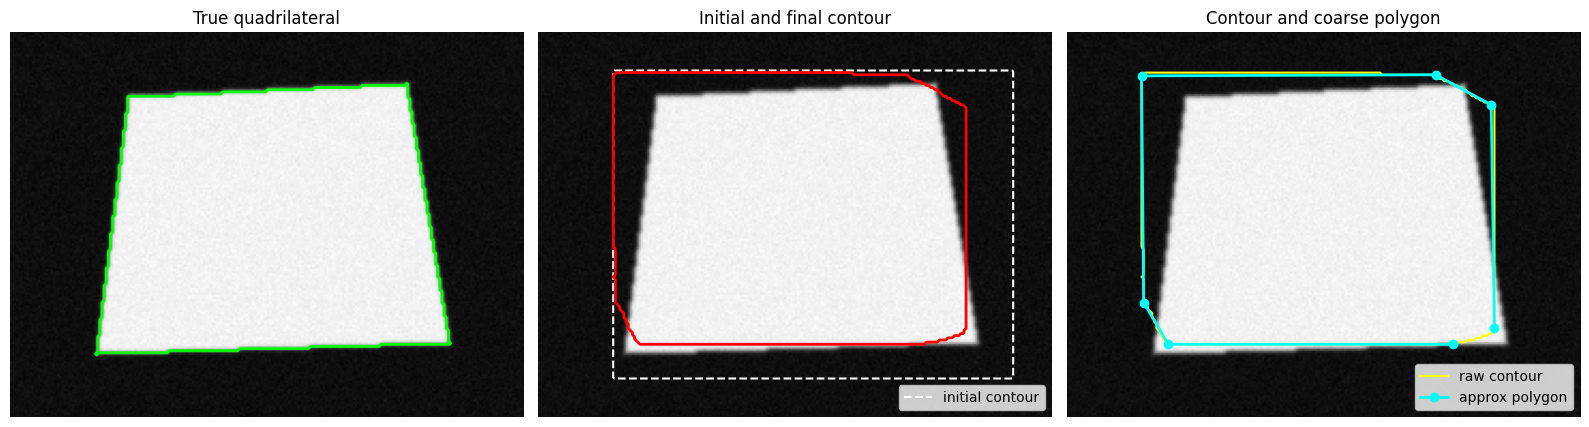

In [13]:
intersection = np.logical_and(pred_mask, true_mask).sum()
union = np.logical_or(pred_mask, true_mask).sum()
iou = float(intersection / union)

contours = measure.find_contours(pred_mask.astype(float), 0.5)
largest_contour = max(contours, key=len)
approx_polygon = measure.approximate_polygon(largest_contour, tolerance=POLYGON_TOLERANCE)
approx_polygon = drop_duplicate_last_vertex(approx_polygon)
pred_left_x = float(largest_contour[:, 1].min())
pred_right_x = float(largest_contour[:, 1].max())
pred_top_y = float(largest_contour[:, 0].min())
pred_bottom_y = float(largest_contour[:, 0].max())

print(f'Predicted mask IoU: {iou:.4f}')
print('Approx polygon vertex count:', len(approx_polygon))
print(f'Final contour bounds: left={pred_left_x:.1f}, right={pred_right_x:.1f}, top={pred_top_y:.1f}, bottom={pred_bottom_y:.1f}')

init_contours = measure.find_contours(init_mask.astype(float), 0.5)
largest_init_contour = max(init_contours, key=len)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(synthetic_img, cmap='gray')
axes[0].contour(true_mask.astype(float), levels=[0.5], colors='lime', linewidths=2)
axes[0].set_title('True quadrilateral')
axes[0].axis('off')

axes[1].imshow(synthetic_img, cmap='gray')
axes[1].plot(largest_init_contour[:, 1], largest_init_contour[:, 0], color='white', linestyle='--', linewidth=1.5, label='initial contour')
axes[1].contour(pred_mask.astype(float), levels=[0.5], colors='red', linewidths=2)
axes[1].set_title('Initial and final contour')
axes[1].axis('off')
axes[1].legend(loc='lower right')

axes[2].imshow(synthetic_img, cmap='gray')
axes[2].plot(largest_contour[:, 1], largest_contour[:, 0], color='yellow', linewidth=1.5, label='raw contour')
axes[2].plot(approx_polygon[:, 1], approx_polygon[:, 0], color='cyan', linewidth=2, marker='o', label='approx polygon')
axes[2].set_title('Contour and coarse polygon')
axes[2].axis('off')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()


## Conclusion

This temporary notebook confirms that **ITK shape-prior active contour works in Python** for our simple synthetic test.

With the improved default parameters in this notebook, the result was:

- predicted-mask IoU about `0.83`
- coarse polygon vertex count `7` after contour simplification

The main fix was to make the initialization **asymmetric**. The left side now starts farther inside the image, so it is less stuck near its first position.
So the contour moves better toward the object, especially on the left edge. We still do not get a clean 4-corner quadrilateral directly, so a later **quadrilateral fitting** step is still likely needed.
